# 01. Introdução aos dados do xadrez

Neste notebook, vou explorar o dataset de partidas de xadrez para entender quais variáveis são mais relevantes para um perceptron binário

O foco principal é usar os ratings dos jogadores para prever o vencedor entre brancas e pretas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Carregando o dataset


In [19]:
df = pd.read_csv('../data/raw/games.csv')
print(f'Tamanho do dataset original: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Tamanho do dataset original: 20058 linhas x 16 colunas


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## Informações básicas

Aqui eu verifico tipos de dados, colunas e valores nulos para conhecer melhor a estrutura do problema

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


## Estatísticas descritivas

Aqui eu analiso as colunas numéricas para entender escala e dispersão dos dados

In [21]:
df[['white_rating', 'black_rating', 'turns', 'opening_ply']].describe()

,white_rating,black_rating,turns,opening_ply
count,20058.000000,20058.000000,20058.000000,20058.000000
mean,1596.631868,1588.831987,60.465999,4.816981
std,291.253376,291.036126,33.570585,2.797152
min,784.000000,789.000000,1.000000,1.000000
25%,1398.000000,1391.000000,37.000000,3.000000
50%,1567.000000,1562.000000,55.000000,4.000000
75%,1793.000000,1784.000000,79.000000,6.000000
max,2700.000000,2723.000000,349.000000,28.000000


## Limpeza e engenharia de dados

Como o perceptron clássico trabalha com classificação binária, removi os empates e criei uma variável alvo binária

Definição da variável alvo:
- `target = 1`: vitória das brancas
- `target = 0`: vitória das pretas

In [5]:
# remove empates
df_filtered = df[df['winner'] != 'draw'].copy()

# cria a coluna target
df_filtered['target'] = df_filtered['winner'].apply(lambda x: 1 if x == 'white' else 0)

# coluna auxiliar para análise
df_filtered['rating_diff'] = df_filtered['white_rating'] - df_filtered['black_rating']

# colunas usadas no perceptron
df_final = df_filtered[['white_rating', 'black_rating', 'rating_diff', 'target']].copy()

print(f'Partidas sem empate: {df_final.shape[0]}')
display(df_final.head())

Partidas sem empate: 19108


,white_rating,black_rating,rating_diff,target
0,1500,1191,309,1
1,1322,1261,61,0
2,1496,1500,-4,1
3,1439,1454,-15,1
4,1523,1469,54,1


## Análise da classe de saída

- classe 1: brancas vencem
- classe 0: pretas vencem

In [6]:
contagem = df_filtered['winner'].value_counts()
proporcao = (contagem / contagem.sum() * 100).round(2)

print('Contagem por classe:')
print(contagem.to_string())
print('\nProporcao por classe (%):')
print(proporcao.to_string())

Contagem por classe:
winner
white    10001
black     9107

Proporcao por classe (%):
winner
white    52.34
black    47.66


## Distribuição de vitórias

Este gráfico mostra o balanceamento das classes que alimentam o perceptron

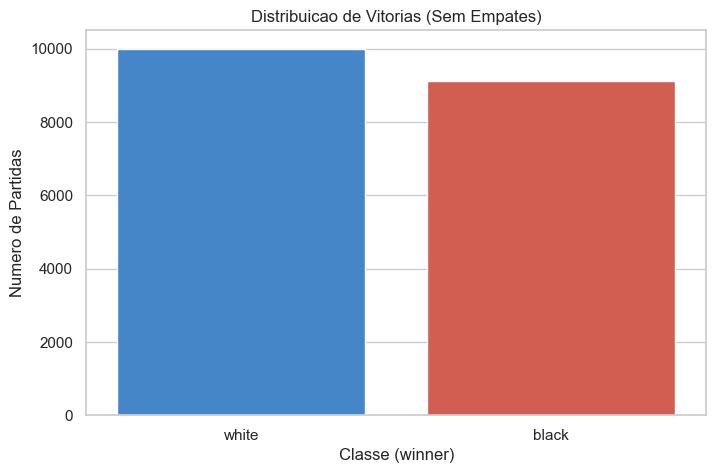

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_filtered, x='winner', hue='winner', palette=['#2E86DE', '#E74C3C'], legend=False)
plt.title('Distribuicao de Vitorias (Sem Empates)')
plt.xlabel('Classe (winner)')
plt.ylabel('Numero de Partidas')
plt.show()

## Fronteira intuitiva de decisão

Neste gráfico, cada ponto é uma partida

A linha tracejada representa igualdade de rating (`white_rating = black_rating`)

Interpretação:
- pontos abaixo da linha: brancas tinham rating maior
- pontos acima da linha: pretas tinham rating maior
- cores mostram a classe real (`target`)

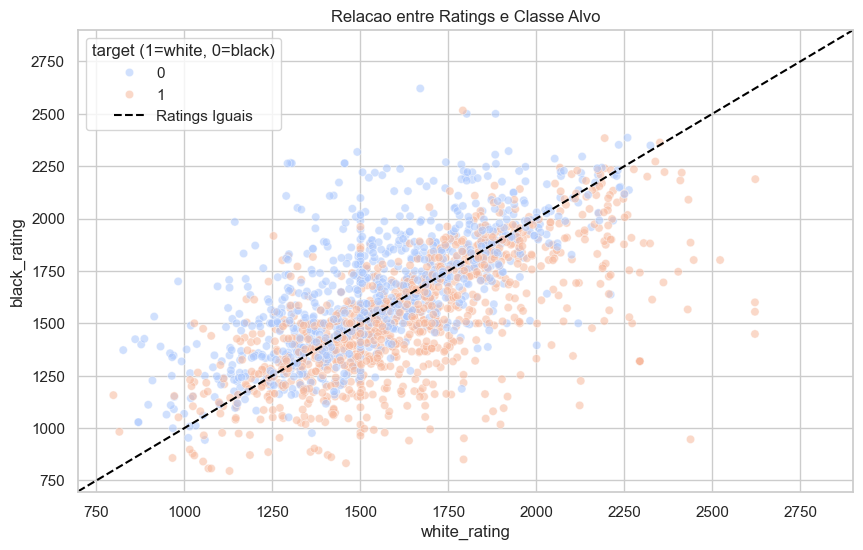

In [9]:
sample_plot = df_final.sample(2000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_plot, x='white_rating', y='black_rating', hue='target', alpha=0.55, palette='coolwarm')
plt.axline((800, 800), (2800, 2800), color='black', linestyle='--', label='Ratings Iguais')
plt.title('Relacao entre Ratings e Classe Alvo')
plt.xlabel('white_rating')
plt.ylabel('black_rating')
plt.legend(title='target (1=white, 0=black)')
plt.show()

## Entradas para o perceptron

- `x1 = white_rating`
- `x2 = black_rating`

Também analisei `rating_diff`, que resume a diferença de força entre os jogadores e ajuda na interpretação do comportamento do modelo

In [10]:
X = df_final[['white_rating', 'black_rating']].values.tolist()
y = df_final['target'].values.tolist()

print('Exemplo de entrada para o Perceptron (x1, x2):', X[0])
print('Exemplo de rotulo esperado (target):', y[0])
print('\nResumo das entradas escolhidas:')
display(df_final[['white_rating', 'black_rating', 'rating_diff', 'target']].head())

Exemplo de entrada para o Perceptron (x1, x2): [1500, 1191]
Exemplo de rotulo esperado (target): 1

Resumo das entradas escolhidas:


,white_rating,black_rating,rating_diff,target
0,1500,1191,309,1
1,1322,1261,61,0
2,1496,1500,-4,1
3,1439,1454,-15,1
4,1523,1469,54,1


## Função do perceptron

A função `predict(white_rating, black_rating)` executa:
- normalização dos ratings
- cálculo da ativação linear (`activation_value`)
- função degrau para gerar a predição final (`White Wins` ou `Black Wins`)

No problema de xadrez:
- `White Wins`: previsão de vitória das brancas
- `Black Wins`: previsão de vitória das pretas

In [ ]:
import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.perceptron import PerceptronXadrez

perceptron = PerceptronXadrez()

resultado_teste = perceptron.predict(1700, 1550)
print(f"z = {resultado_teste['activation_value']:.4f}")
print("Predicao:", resultado_teste['prediction'])
print("Entradas normalizadas:", resultado_teste['inputs_normalized'])

z = 0.0750
Predicao: White Wins
Entradas normalizadas: {'white': 0.45, 'black': 0.375}


## Exemplos de funcionamento no dataset

Aqui eu aplico diretamente `PerceptronXadrez.predict(...)` em exemplos reais do dataset e comparo a previsão da classe com o resultado real (`target`)

In [18]:
amostra = df_final.sample(10, random_state=7).copy()

map_pred_to_target = {'White Wins': 1, 'Black Wins': 0}

def prever_linha(row):
    resultado = perceptron.predict(row['white_rating'], row['black_rating'])
    return pd.Series({
        'prediction': resultado['prediction'],
        'z': resultado['activation_value'],
        'pred_target': map_pred_to_target[resultado['prediction']]
    })

amostra[['prediction', 'z', 'pred_target']] = amostra.apply(prever_linha, axis=1)
amostra['acertou'] = (amostra['pred_target'] == amostra['target']).astype(int)

display(amostra[['white_rating', 'black_rating', 'rating_diff', 'target', 'prediction', 'pred_target', 'z', 'acertou']])

,white_rating,black_rating,rating_diff,target,prediction,pred_target,z,acertou
12151,1688,1899,-211,0,Black Wins,0,-0.1055,1
999,1704,1862,-158,1,Black Wins,0,-0.0790,0
19302,1652,1739,-87,0,Black Wins,0,-0.0435,1
12789,1621,1894,-273,0,Black Wins,0,-0.1365,1
13388,1311,1611,-300,1,Black Wins,0,-0.1500,0
19669,999,1368,-369,0,Black Wins,0,-0.1845,1
10907,1286,1280,6,1,White Wins,1,0.0030,1
10785,1670,1432,238,1,White Wins,1,0.1190,1
10300,1777,1453,324,1,White Wins,1,0.1620,1
14100,1317,1233,84,1,White Wins,1,0.0420,1
